In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from torch.optim.lr_scheduler import StepLR

In [2]:
class MVTecLOCODataset(Dataset):
    def __init__(self, root_dir, split='train', anomaly_type='logical_anomalies', transform=None):
        """
        Args:
            root_dir (string): Base directory of the 'screw_bag' dataset.
            split (string): 'train', 'test', or 'validation'.
            anomaly_type (string): Type of anomalies to consider ('logical_anomalies' or 'structural_anomalies').
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.transform = transform
        self.image_paths = []
        self.labels = []  # 0 for normal, 1 for anomaly
        self.img_filenames = []

        if split == 'train':
            # Load 'good' images for training
            good_dir = os.path.join(root_dir, 'train', 'good')
            self._load_images_from_folder(good_dir, label=0)
        elif split == 'test':
            # Load 'good' and specified anomalies for testing
            good_dir = os.path.join(root_dir, 'test', 'good')
            anomaly_dir = os.path.join(root_dir, 'test', anomaly_type)
            self._load_images_from_folder(good_dir, label=0)
            self._load_images_from_folder(anomaly_dir, label=1)
        elif split == 'validation':
            # Implement validation data loading if needed
            pass  # Placeholder
        else:
            raise ValueError(f"Invalid split: {split}")

    def _load_images_from_folder(self, folder, label):
        if not os.path.isdir(folder):
            print("FOLDER IS MISSING!!!")
            return
        for root, _, files in os.walk(folder):
            for file in files:
                if file.endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(root, file)
                    self.image_paths.append(img_path)
                    self.labels.append(label)
                    self.img_filenames.append(file)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label, img_path

# Assume MVTecLOCODataset is already defined
# def main():
#     # Dataset root directory
#     dataset_root = '/home/hafiz/my_thesis/seg_recons/dataset/screw_bag'  # Replace with your dataset path

#     # Data transformations
#     transform = transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                              std=[0.229, 0.224, 0.225]),
#     ])

#     # Training DataLoader
#     train_dataset = MVTecLOCODataset(root_dir=dataset_root, split='train', transform=transform)
#     train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

#     # Testing DataLoader
#     test_dataset = MVTecLOCODataset(root_dir=dataset_root, split='test', anomaly_type='logical_anomalies', transform=transform)
#     test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

#     # Iterate over training data
#     for images, labels, img_paths in train_loader:
#         print(f'Training batch - Images shape: {images.shape}, Labels: {labels}')
#         # Proceed with training...
#         break  # Remove this break to iterate over all batches

#     # Iterate over testing data
#     for images, labels, img_paths in test_loader:
#         print(f'Testing image - Image shape: {images.shape}, Label: {labels.item()}, Path: {img_paths[0]}')
#         # Proceed with evaluation...
#         break  # Remove this break to iterate over all images

#     # Visualize some training images
#     visualize_dataset_samples(train_dataset)

#     # Visualize some testing images
#     visualize_dataset_samples(test_dataset)

# def visualize_dataset_samples(dataset, num_samples=5):
#     for i in range(num_samples):
#         image, label, img_path = dataset[i]
#         # Denormalize the image for display
#         mean = np.array([0.485, 0.456, 0.406])
#         std = np.array([0.229, 0.224, 0.225])
#         image_np = image.numpy().transpose((1, 2, 0))
#         image_np = std * image_np + mean
#         image_np = np.clip(image_np, 0, 1)

#         plt.imshow(image_np)
#         plt.title(f'Label: {"Anomaly" if label == 1 else "Normal"}')
#         plt.axis('off')
#         plt.show()

# if __name__ == '__main__':
#     main()

In [3]:
class ViTVAE(nn.Module):
    def __init__(self, pretrained=True, latent_dim=256):
        super(ViTVAE, self).__init__()
        # Load pretrained ViT
        if pretrained:
            weights = ViT_B_16_Weights.IMAGENET1K_V1
        else:
            weights = None
        self.encoder = vit_b_16(weights=weights)
        self.encoder.heads = nn.Identity()  # Remove classification head

        # Get the embedding dimension from ViT
        embedding_dim = self.encoder.hidden_dim  # Typically 768 for ViT-B/16

        # VAE's latent space
        self.fc_mu = nn.Linear(embedding_dim, latent_dim)
        self.fc_logvar = nn.Linear(embedding_dim, latent_dim)

        # Decoder
        # Map latent vector back to embedding dimension
        self.decoder_input = nn.Linear(latent_dim, embedding_dim)

        # Decoder with increased depth and upsampling
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 768 * 7 * 7),
            nn.ReLU(inplace=True),
            nn.Unflatten(1, (768, 7, 7)),  # Shape: (batch_size, 768, 7, 7)

            # Upsampling blocks
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # (batch_size, 768, 14, 14)
            nn.Conv2d(768, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # (batch_size, 512, 28, 28)
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # (batch_size, 256, 56, 56)
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # (batch_size, 128, 112, 112)
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # (batch_size, 64, 224, 224)
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid(),  # Output images in [0, 1]
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Encode
        x = self.encoder(x)  # Shape: (batch_size, embedding_dim)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)

        # Decode
        recon_x = self.decoder(z)
        return recon_x, mu, logvar


# class ViTVAE(nn.Module):
#     def __init__(self, pretrained=True, latent_dim=256):
#         super(ViTVAE, self).__init__()
#         # Load pretrained ViT
#         if pretrained:
#             weights = ViT_B_16_Weights.IMAGENET1K_V1
#         else:
#             weights = None
#         self.encoder = vit_b_16(weights=weights)
#         self.encoder.heads = nn.Identity()  # or self.encoder.head = nn.Identity()

#         # Get the embedding dimension from ViT
#         embedding_dim = self.encoder.hidden_dim

#         # VAE's latent space
#         self.fc_mu = nn.Linear(embedding_dim, latent_dim)
#         self.fc_logvar = nn.Linear(embedding_dim, latent_dim)

        # # Decoder
        # self.decoder = nn.Sequential(
        #     nn.Linear(latent_dim, embedding_dim),
        #     nn.ReLU(),
        #     nn.Linear(embedding_dim, 512 * 7 * 7),
        #     nn.ReLU(),
        #     nn.Unflatten(1, (512, 7, 7)),
        #     nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, output_padding=1),
        #     nn.ReLU(),
        #     nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, output_padding=1),
        #     nn.ReLU(),
        #     nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, output_padding=1),
        #     nn.ReLU(),
        #     nn.ConvTranspose2d(64, 3, kernel_size=3, stride=1),
        #     nn.Sigmoid(),  # Assuming images are normalized between 0 and 1
        # )

    #     self.decoder = nn.Sequential(
    #         nn.Linear(latent_dim, 512 * 7 * 7),
    #         nn.ReLU(),
    #         nn.Unflatten(1, (512, 7, 7)),
    #         nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # Output: [batch_size, 256, 14, 14]
    #         nn.ReLU(),
    #         nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # Output: [batch_size, 128, 28, 28]
    #         nn.ReLU(),
    #         nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # Output: [batch_size, 64, 56, 56]
    #         nn.ReLU(),
    #         nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # Output: [batch_size, 32, 112, 112]
    #         nn.ReLU(),
    #         nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),     # Output: [batch_size, 3, 224, 224]
    #         nn.Sigmoid(),
    #     )


    # def reparameterize(self, mu, logvar):
    #     std = torch.exp(0.5 * logvar)
    #     eps = torch.randn_like(std)
    #     return mu + eps * std

    # def forward(self, x):
    #     # Encode
    #     x = self.encoder(x)
    #     mu = self.fc_mu(x)
    #     logvar = self.fc_logvar(x)
    #     z = self.reparameterize(mu, logvar)

    #     # Decode
    #     recon_x = self.decoder(z)
    #     return recon_x, mu, logvar

In [4]:
def evaluate(model, dataloader, device):
    model.eval()
    anomaly_scores = []
    labels = []

    with torch.no_grad():
        for images, targets, _ in tqdm(dataloader):
            images = images.to(device)
            recon_images, _, _ = model(images)
            # Compute reconstruction error per sample
            recon_errors = torch.mean((images - recon_images) ** 2, dim=[1, 2, 3])
            anomaly_scores.extend(recon_errors.cpu().numpy())
            labels.extend(targets.cpu().numpy())

    # Compute ROC AUC
    roc_auc = roc_auc_score(labels, anomaly_scores)
    print(f'ROC AUC Score for Logical Anomalies: {roc_auc:.4f}')
    return roc_auc


In [5]:
def visualize_reconstruction(model, dataloader, device, num_images=5):
    model.eval()
    images_shown = 0

    with torch.no_grad():
        for images, labels, _ in dataloader:
            images = images.to(device)
            recon_images, _, _ = model(images)

            for i in range(images.size(0)):
                if images_shown >= num_images:
                    return
                orig = images[i].cpu().permute(1, 2, 0).numpy()
                recon = recon_images[i].cpu().permute(1, 2, 0).numpy()
                diff = np.abs(orig - recon)

                # Denormalize images
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                orig = std * orig + mean
                recon = std * recon + mean

                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                axs[0].imshow(np.clip(orig, 0, 1))
                axs[0].set_title('Original Image')
                axs[0].axis('off')

                axs[1].imshow(np.clip(recon, 0, 1))
                axs[1].set_title('Reconstructed Image')
                axs[1].axis('off')

                axs[2].imshow(np.clip(diff, 0, 1), cmap='hot')
                axs[2].set_title('Difference')
                axs[2].axis('off')

                plt.suptitle(f'Label: {"Anomaly" if labels[i].item() == 1 else "Normal"}')
                plt.show()
                images_shown += 1


In [6]:
def loss_function(recon_x, x, mu, logvar, kl_weight=1.0):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='mean')
    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_weight * kld

def train_epoch(model, dataloader, optimizer, device, kl_weight=0.1):
    model.train()
    train_loss = 0
    for images, labels, _ in dataloader:
        images = images.to(device)
        optimizer.zero_grad()
        recon_images, mu, logvar = model(images)
        loss = loss_function(recon_images, images, mu, logvar, kl_weight)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    avg_loss = train_loss / len(dataloader)
    return avg_loss


# def train_epoch(model, dataloader, optimizer, device):
#     model.train()
#     train_loss = 0
#     for images, labels, _ in dataloader:
#         images = images.to(device)
#         optimizer.zero_grad()
#         recon_images, mu, logvar = model(images)
#         loss = loss_function(recon_images, images, mu, logvar)
#         loss.backward()
#         train_loss += loss.item()
#         optimizer.step()
#     avg_loss = train_loss / len(dataloader)
#     return avg_loss

Epoch [1/100], Loss: 2.7997
Epoch [2/100], Loss: 2.5519
Epoch [3/100], Loss: 2.4091
Epoch [4/100], Loss: 2.2927
Epoch [5/100], Loss: 2.1883
Epoch [6/100], Loss: 2.0935
Epoch [7/100], Loss: 2.0193
Epoch [8/100], Loss: 1.9597
Epoch [9/100], Loss: 1.9115
Epoch [10/100], Loss: 1.8759
Epoch [11/100], Loss: 1.8499
Epoch [12/100], Loss: 1.8377
Epoch [13/100], Loss: 1.8253
Epoch [14/100], Loss: 1.8147
Epoch [15/100], Loss: 1.8054
Epoch [16/100], Loss: 1.7990
Epoch [17/100], Loss: 1.7918
Epoch [18/100], Loss: 1.7843
Epoch [19/100], Loss: 1.7782
Epoch [20/100], Loss: 1.7723
Epoch [21/100], Loss: 1.7691
Epoch [22/100], Loss: 1.7677
Epoch [23/100], Loss: 1.7637
Epoch [24/100], Loss: 1.7645
Epoch [25/100], Loss: 1.7608
Epoch [26/100], Loss: 1.7610
Epoch [27/100], Loss: 1.7570
Epoch [28/100], Loss: 1.7561
Epoch [29/100], Loss: 1.7547
Epoch [30/100], Loss: 1.7534
Epoch [31/100], Loss: 1.7515
Epoch [32/100], Loss: 1.7496
Epoch [33/100], Loss: 1.7505
Epoch [34/100], Loss: 1.7487
Epoch [35/100], Loss: 1

100%|██████████| 259/259 [00:06<00:00, 41.92it/s]

ROC AUC Score for Logical Anomalies: 0.5473
ROC AUC Score for Logical Anomalies with latent_dim 128: 0.5473


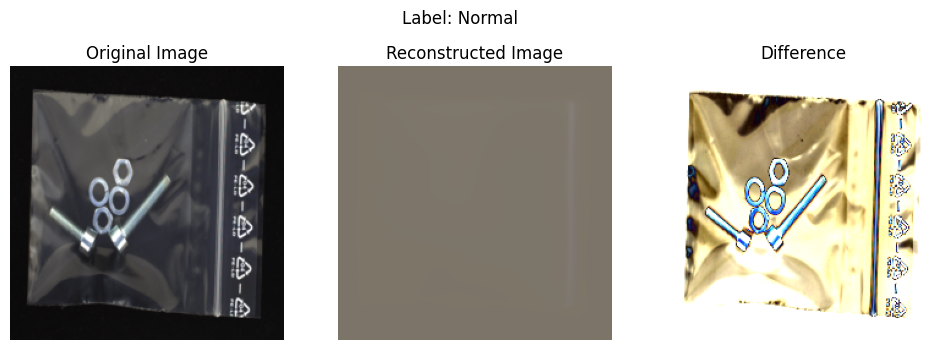

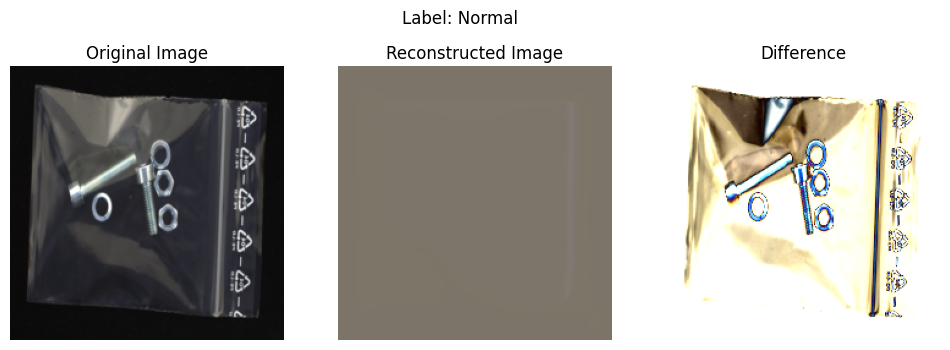

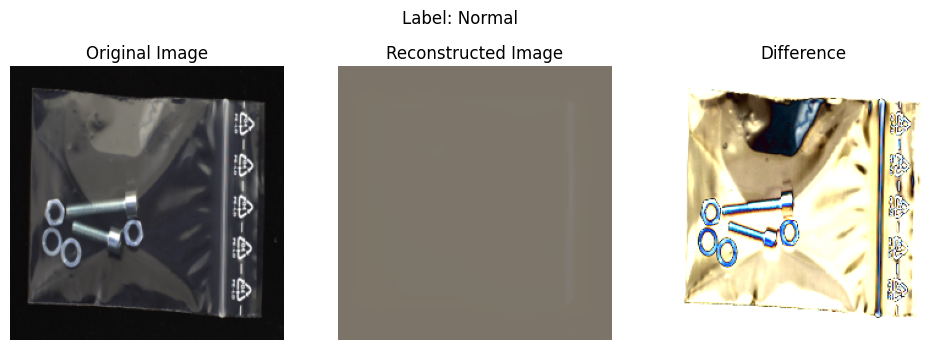

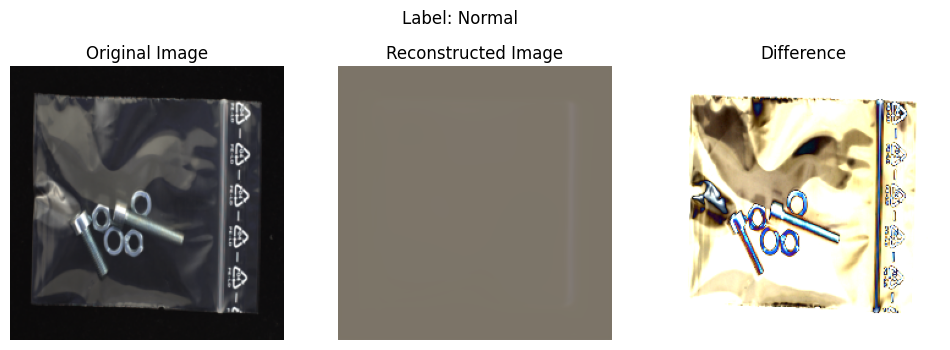

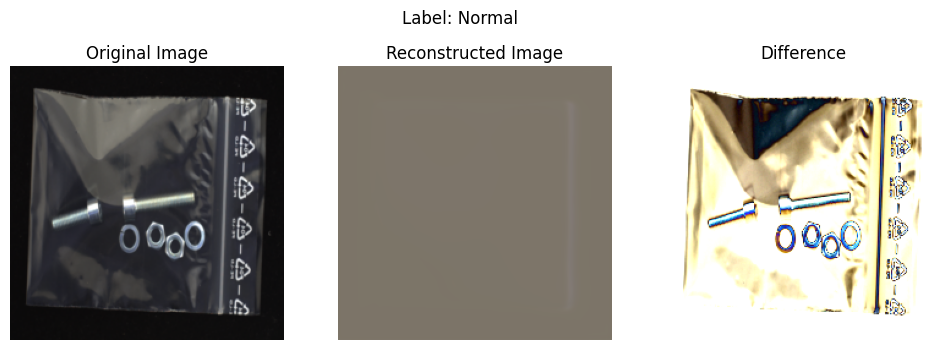

In [7]:
def main():
    # Hyperparameters
    batch_size = 16
    num_epochs = 100
    learning_rate = 1e-4
    latent_dim = 128  # Adjust as needed
    kl_weight = 0.1   # Adjust to balance losses
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # # Data transformations with augmentation
    # transform = transforms.Compose([
    #     transforms.Resize((224, 224)),
    #     transforms.RandomHorizontalFlip(),
    #     transforms.RandomRotation(10),
    #     transforms.ColorJitter(brightness=0.1, contrast=0.1),
    #     transforms.ToTensor(),
    #     transforms.Normalize(mean=[0.485, 0.456, 0.406],
    #                          std=[0.229, 0.224, 0.225]),
    # ])

    # Data transformations
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # ViT expects 224x224 images
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ViT's expected normalization
                             std=[0.229, 0.224, 0.225]),
    ])    

    # Dataset root directory
    dataset_root = '/home/hafiz/my_thesis/seg_recons/dataset/screw_bag'

    # Training DataLoader
    train_dataset = MVTecLOCODataset(root_dir=dataset_root, split='train', transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

    # Testing DataLoader
    test_dataset = MVTecLOCODataset(root_dir=dataset_root, split='test', anomaly_type='logical_anomalies', transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)

    # Model and Optimizer
    model = ViTVAE(pretrained=True, latent_dim=latent_dim).to(device)
    # Enable fine-tuning
    for param in model.encoder.parameters():
        param.requires_grad = True
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    # Training Loop
    for epoch in range(num_epochs):
        avg_loss = train_epoch(model, train_loader, optimizer, device, kl_weight)
        scheduler.step()
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    # Save the trained model
    torch.save(model.state_dict(), f'vit_vae_latent_{latent_dim}.pth')

    # Evaluation
    roc_auc = evaluate(model, test_loader, device)
    print(f'ROC AUC Score for Logical Anomalies with latent_dim {latent_dim}: {roc_auc:.4f}')

    # Visualization
    visualize_reconstruction(model, test_loader, device, num_images=5)

if __name__ == '__main__':
    main()


Epoch [1/50], Loss: 3.0034
Epoch [2/50], Loss: 2.1700
Epoch [3/50], Loss: 1.7473
Epoch [4/50], Loss: 1.7264
Epoch [5/50], Loss: 1.7169
Epoch [6/50], Loss: 1.7119
Epoch [7/50], Loss: 1.7121
Epoch [8/50], Loss: 1.7118
Epoch [9/50], Loss: 1.7098
Epoch [10/50], Loss: 1.7100
Epoch [11/50], Loss: 1.7098
Epoch [12/50], Loss: 1.7092
Epoch [13/50], Loss: 1.7100
Epoch [14/50], Loss: 1.7088
Epoch [15/50], Loss: 1.7091
Epoch [16/50], Loss: 1.7088
Epoch [17/50], Loss: 1.7094
Epoch [18/50], Loss: 1.7097
Epoch [19/50], Loss: 1.7098
Epoch [20/50], Loss: 1.7100
Epoch [21/50], Loss: 1.7103
Epoch [22/50], Loss: 1.7100
Epoch [23/50], Loss: 1.7086
Epoch [24/50], Loss: 1.7095
Epoch [25/50], Loss: 1.7102
Epoch [26/50], Loss: 1.7090
Epoch [27/50], Loss: 1.7098
Epoch [28/50], Loss: 1.7082
Epoch [29/50], Loss: 1.7098
Epoch [30/50], Loss: 1.7078
Epoch [31/50], Loss: 1.7098
Epoch [32/50], Loss: 1.7097
Epoch [33/50], Loss: 1.7099
Epoch [34/50], Loss: 1.7090
Epoch [35/50], Loss: 1.7099
Epoch [36/50], Loss: 1.7092
E

100%|██████████| 259/259 [00:06<00:00, 41.80it/s]


ROC AUC Score for Logical Anomalies: 0.5461


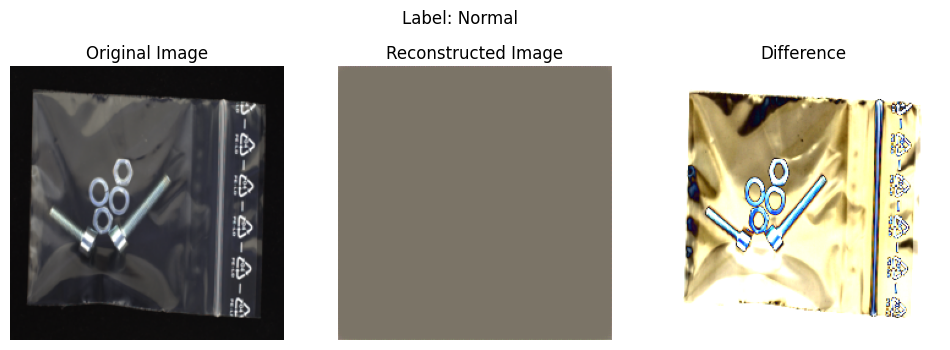

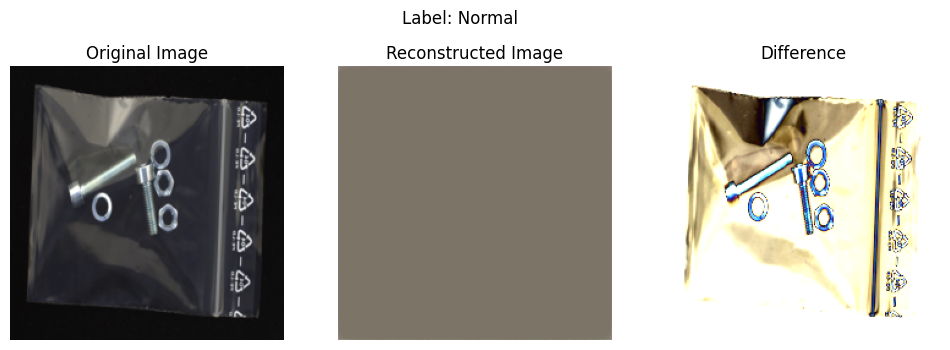

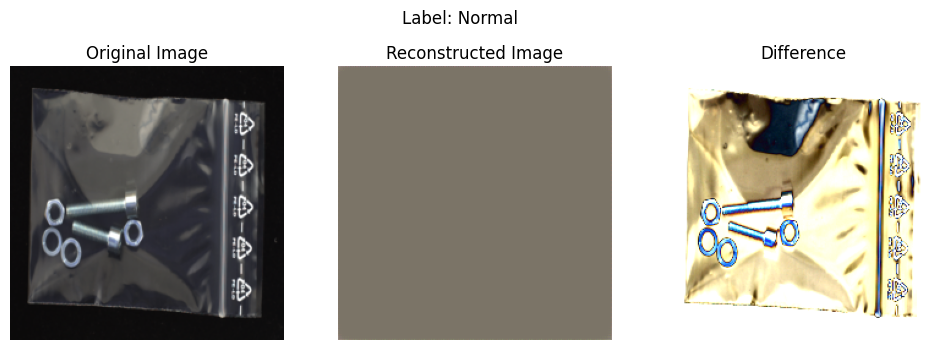

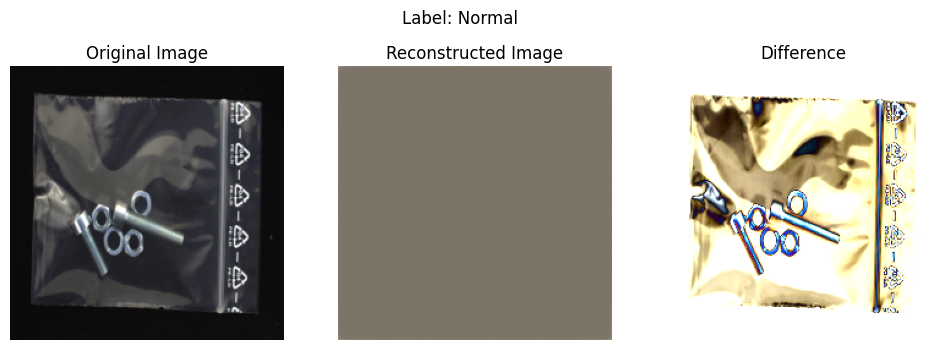

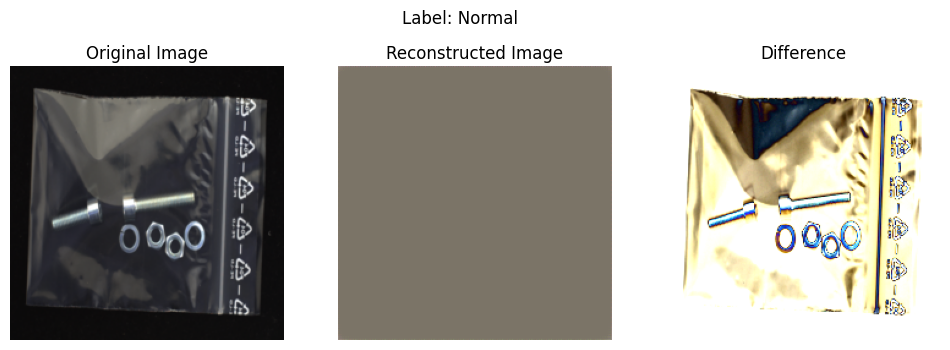

In [8]:
# def main():
#     # Hyperparameters
#     batch_size = 16
#     num_epochs = 50
#     learning_rate = 1e-4
#     latent_dim = 256
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#     # Data transformations
#     transform = transforms.Compose([
#         transforms.Resize((224, 224)),  # ViT expects 224x224 images
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ViT's expected normalization
#                              std=[0.229, 0.224, 0.225]),
#     ])

#     # Dataset root directory
#     dataset_root = '/home/hafiz/my_thesis/seg_recons/dataset/screw_bag'

#     # Training DataLoader
#     train_dataset = MVTecLOCODataset(root_dir=dataset_root, split='train', transform=transform)
#     train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

#     # Model and Optimizer
#     model = ViTVAE(pretrained=True, latent_dim=latent_dim).to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

#     # After optimizer initialization
#     scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

#     # Training Loop
#     for epoch in range(num_epochs):
#         avg_loss = train_epoch(model, train_loader, optimizer, device)
#         print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
#         scheduler.step()

#         if (epoch + 1) % 5 == 0:
#             torch.save(model.state_dict(), f'vit_vae_epoch_{epoch+1}.pth')

#     # Save the trained model
#     torch.save(model.state_dict(), 'vit_vae_mvtec_loco_screw_bag.pth')

#     # Testing DataLoader
#     test_dataset = MVTecLOCODataset(root_dir=dataset_root, split='test', anomaly_type='logical_anomalies', transform=transform)
#     test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)

#     # Evaluation
#     roc_auc = evaluate(model, test_loader, device)

#     # Visualization
#     visualize_reconstruction(model, test_loader, device, num_images=5)

